<a href="https://colab.research.google.com/github/tamyressilvazz/machine-learning-p05/blob/main/Exerc%C3%ADcio_Interprelabilidade_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Pré-processamento e modelo: Use o conjunto de dados Diabetes (no Classroom da turma). Treine um RandomForestClassifier e avalie o modelo usando acurácia, precisão, cobertura, f1 e AUC no conjunto de teste.**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/My Drive/datasets/diabetes.csv')

df.head()

,preg,plas,pres,skin,insu,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,tested_positive
1,1,85,66,29,0,26.6,0.351,31,tested_negative
2,8,183,64,0,0,23.3,0.672,32,tested_positive
3,1,89,66,23,94,28.1,0.167,21,tested_negative
4,0,137,40,35,168,43.1,2.288,33,tested_positive


In [ ]:
df['class'] = df['class'].map({
    'tested_negative': 0,
    'tested_positive': 1
})

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['class'])
Y = df['class']

# Separando os dados em treinamento(70%) e teste(30%)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.30)


In [ ]:
from sklearn.inspection import PartialDependenceDisplay

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier().fit(X_train, Y_train)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Previsões do modelo
y_pred = rf.predict(X_test)

# Probabilidade da classe positiva (necessário para AUC)
y_prob = rf.predict_proba(X_test)[:, 1]

In [ ]:
Yhat = rf.predict(X_test)

Yhat

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
# Métricas
accuracy = accuracy_score(Y_test, y_pred)
precision = precision_score(Y_test, y_pred)
recall = recall_score(Y_test, y_pred)
f1 = f1_score(Y_test, y_pred)
auc = roc_auc_score(Y_test, y_prob)

print("Acurácia :", accuracy)
print("Precisão :", precision)
print("Cobertura (Recall) :", recall)
print("F1-score :", f1)
print("AUC :", auc)

Acurácia : 0.7662337662337663
Precisão : 0.7142857142857143
Cobertura (Recall) : 0.5555555555555556
F1-score : 0.625
AUC : 0.7920987654320988


Acurácia (0.766)
Indica que aproximadamente 76,6% das previsões do modelo estão corretas no conjunto de teste.

Precisão (0.714)
Entre os casos que o modelo previu como diabetes, cerca de 71,4% realmente são positivos.

Recall / Cobertura (0.556)
O modelo consegue identificar 55,6% dos casos reais de diabetes. Isso mostra que alguns casos positivos ainda não estão sendo detectados.

F1-score (0.625)
O F1-score é a média harmônica entre precisão e recall. O valor 0.625 indica um equilíbrio moderado entre detectar casos positivos e evitar falsos positivos.

AUC (0.792)
A AUC mede a capacidade do modelo de distinguir entre as classes. Um valor de 0.79 indica boa capacidade de separação entre pacientes com e sem diabetes.

**2. PFI — Permutation Feature Importance:  Use sklearn.inspection.permutation_importance no conjunto de teste. Extraia a importância média e o desvio padrão das features. Plote um gráfico de barras ordenando pela importância. Interprete:
Quais features mais impactam o desempenho do modelo?
Há alguma diferença comparando com a importância interna do Random Forest?**

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    rf,
    X_test,
    Y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Extraindo média e desvio padrão
importance_mean = result.importances_mean
importance_std = result.importances_std

# Organizando em um DataFrame
feature_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": importance_mean,
    "Importance Std": importance_std
})

# Ordenando da mais importante para a menos importante
feature_importance = feature_importance.sort_values(
    by="Importance Mean",
    ascending=False
)

print(feature_importance)

  Feature  Importance Mean  Importance Std
1    plas         0.104762        0.017510
5    mass         0.055844        0.012313
7     age         0.030303        0.012695
6    pedi         0.015152        0.010823
2    pres         0.013853        0.009641
3    skin         0.007359        0.010435
0    preg         0.006061        0.012576
4    insu         0.005195        0.004242


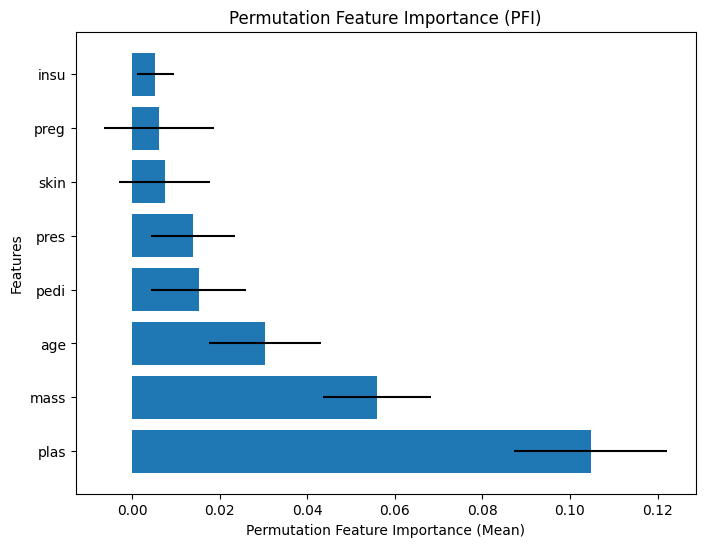

In [ ]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(8,6))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance Mean"],
    xerr=feature_importance["Importance Std"]
)

plt.title("Permutation Feature Importance (PFI)")
plt.xlabel("Permutation Feature Importance (Mean)")
plt.ylabel("Features")
plt.show()


**As variáveis que mais contribuíram para a previsão dessa instância são:**

age ≤ 24 – idade baixa contribuiu para reduzir a probabilidade prevista de diabetes, favorecendo a classificação como No Diabetes.

1 ≤ preg ≤ 3 – poucas gestações também influenciaram a previsão na direção de No Diabetes.

62 ≤ pres ≤ 70 – valores moderados de pressão arterial tiveram pequena contribuição para diminuir o risco previsto.

Por outro lado, algumas variáveis contribuíram para aumentar a probabilidade da classe Diabetes:

115 < plas ≤ 141 – níveis mais altos de glicose no plasma aumentaram a probabilidade prevista de diabetes.

27.30 < mass ≤ 32.00 – um IMC nessa faixa também contribuiu positivamente para o risco de diabetes.

0.37 < pedi ≤ 0.64 – o histórico familiar de diabetes teve uma pequena influência na previsão.

Sim, pode haver algumas diferenças ao comparar a Permutation Feature Importance (PFI) com a importância interna do Random Forest.

A importância interna do Random Forest é calculada com base na redução de impureza (Gini ou Entropy) gerada por cada variável durante as divisões das árvores no treinamento. Assim, ela indica quais variáveis foram mais utilizadas pelo modelo para separar as classes.

Já a Permutation Feature Importance (PFI) mede diretamente o impacto de cada variável no desempenho do modelo, embaralhando seus valores e observando quanto a performance diminui. Se o desempenho cair bastante, significa que a variável é importante para as previsões.

R.: Pode haver pequenas diferenças entre a importância interna do Random Forest e a PFI, pois cada método utiliza critérios diferentes para medir a relevância das variáveis. No entanto, no modelo analisado, ambas as abordagens tendem a destacar plas, mass e age como as features mais importantes para a previsão de diabetes.

**3. PDP 1D: Use sklearn.inspection.PartialDependenceDisplay para plotar os PDPs. Escolha 3 features relevantes e plote o PDP 1D (kind = 'average') para cada uma. Interprete: “Como o índice de massa corporal influencia a previsão do progresso da doença?”**

In [ ]:
print(X_test.columns)

Index(['preg', 'plas', 'pres', 'skin', 'insu', 'mass', 'pedi', 'age'], dtype='object')


In [ ]:
import matplotlib.pyplot as plt

# 3 features mais importantes
features = ["mass", "insu", "age"]

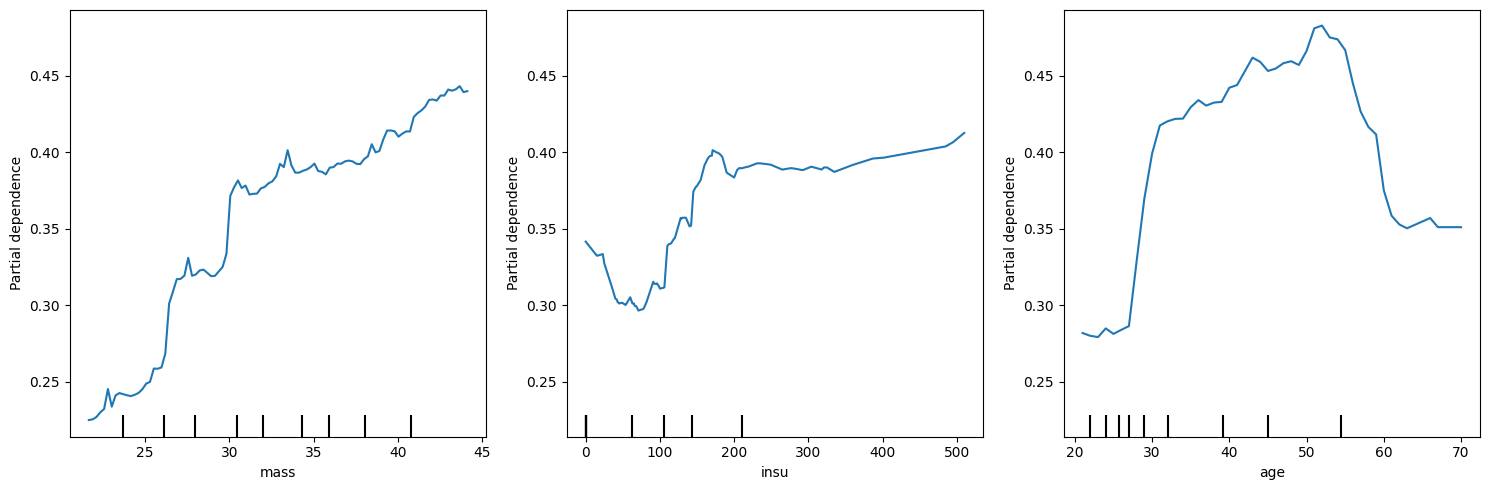

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt



fig, ax = plt.subplots(figsize=(15,5), ncols=3)

PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    features,
    ax=ax,
    kind="average",
)

plt.tight_layout()
plt.show()

IMC (mass)

Para valores mais baixos de IMC (aprox. 22–27), a dependência parcial é menor, indicando menor probabilidade prevista de diabetes.

Entre aproximadamente 27 e 32, observa-se um aumento mais acentuado na curva, sugerindo que o aumento do IMC nessa faixa eleva significativamente a probabilidade prevista pelo modelo.

Após cerca de 33, a curva continua crescendo de forma mais gradual, indicando que valores mais altos de IMC continuam aumentando a probabilidade prevista de diabetes.

R.: O Partial Dependence Plot indica que valores maiores de IMC tendem a aumentar a probabilidade prevista de diabetes, mostrando uma relação positiva entre essa variável e a previsão do modelo.

Insulina (insu)

Para valores mais baixos de insulina (aprox. 0–80), a dependência parcial do modelo é menor, indicando menor probabilidade prevista de diabetes.

Entre aproximadamente 100 e 180, observa-se um aumento mais acentuado na curva, sugerindo que níveis intermediários de insulina aumentam a probabilidade prevista pelo modelo.

Após cerca de 200, a curva apresenta pequenas oscilações e tende a se estabilizar, indicando que aumentos adicionais na insulina têm impacto menor na previsão.

Em valores muito altos (acima de ~400), a curva volta a crescer levemente, mostrando pequeno aumento na probabilidade prevista.

R.: O PDP mostra que níveis mais altos de insulina tendem a aumentar a probabilidade prevista de diabetes, principalmente em valores intermediários, embora o efeito não seja totalmente linear.

Idade (age)

Para idades mais baixas (aprox. 20–30 anos), a dependência parcial é menor, indicando menor probabilidade prevista de diabetes.

Entre 30 e 50 anos, observa-se um aumento gradual da curva, sugerindo que o risco previsto de diabetes cresce com o aumento da idade.

Por volta de 50–55 anos, a probabilidade prevista atinge seus valores mais altos.

Após aproximadamente 60 anos, a curva apresenta uma queda, indicando redução na probabilidade prevista pelo modelo para idades mais avançadas.

R.: O Partial Dependence Plot indica que a idade influencia a previsão do modelo, com aumento da probabilidade de diabetes até aproximadamente a meia-idade, seguido de uma leve redução em idades mais elevadas.

**4 PDP 2D (Interação): Escolha duas features com provável interação (ex.: bmi × bp). Plote o PDP 2D (kind = 'average'). Interprete: “Como a combinação de IMC e pressão arterial influencia a previsão do modelo?”**

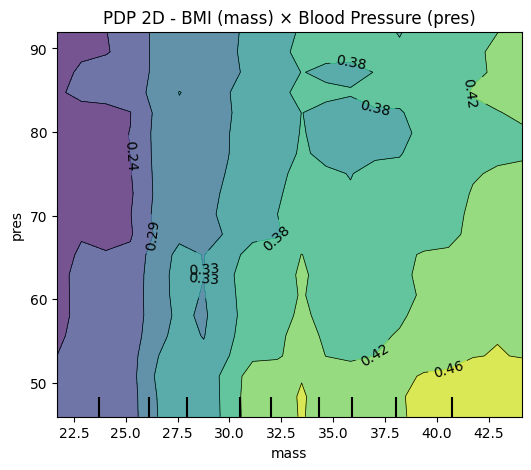

In [ ]:
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6,5))

PartialDependenceDisplay.from_estimator(
    rf,
    X_test,
    features=[("mass", "pres")],
    kind="average",
    ax=ax,
    target = "setosa",
    grid_resolution=20
)

plt.title("PDP 2D - BMI (mass) × Blood Pressure (pres)")
plt.show()

IMC baixo (aprox. 22–26)

A previsão do modelo é menor (regiões mais escuras, valores próximos de 0.24–0.29).

Isso indica menor probabilidade prevista de diabetes para indivíduos com IMC mais baixo.

IMC médio (aprox. 27–33)

Observa-se um aumento gradual na probabilidade prevista, com valores próximos de 0.33–0.38.

Isso sugere que o aumento do IMC nessa faixa começa a elevar o risco previsto pelo modelo.

IMC alto (acima de ~35)

A probabilidade prevista aumenta ainda mais (regiões mais claras, valores próximos de 0.42–0.46).

Isso indica que valores mais elevados de IMC estão associados a maior probabilidade prevista de diabetes.

Influência da pressão arterial

A pressão arterial também influencia a previsão, porém com efeito menor que o IMC.

Em alguns níveis mais baixos de pressão arterial combinados com IMC alto, aparecem as maiores probabilidades previstas no gráfico.

R.: O PDP 2D indica que o IMC exerce forte influência na previsão do modelo, com aumento da probabilidade de diabetes conforme o IMC cresce. A pressão arterial também contribui para a previsão, porém com impacto menor. A combinação de IMC elevado e determinados níveis de pressão arterial está associada às maiores probabilidades previstas de diabetes segundo o modelo Random Forest.

**5. LIME:
Crie um LimeTabularExplainer usando os dados de treino. Explique uma instância do teste. Interprete: Quais features mais contribuíram para a previsão da instância?**

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=926ddae100f365c52daadec3ccabae3d75399f84d21508dbcf97035c51a231fc
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    class_names=["No Diabetes", "Diabetes"],
    mode="classification"
)

In [ ]:
exp = explainer.explain_instance(
    X_test.iloc[2].values,
    rf.predict_proba
)

exp.show_in_notebook()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


O modelo previu:  No Diabetes: 0.70

Diabetes: 0.30, ou seja, o modelo classificou essa instância como No Diabetes.

**Contribuindo para No Diabetes**

As variáveis que mais puxaram a previsão para No Diabetes foram:

age ≤ 24 → idade baixa contribuiu para reduzir o risco previsto.

1 ≤ preg ≤ 3 → poucas gestações também reduziram a probabilidade de diabetes.

insu ≤ 0 → nível de insulina baixo contribuiu levemente para a classe negativa.

62 ≤ pres ≤ 70 → pressão arterial nessa faixa também favoreceu a previsão de não diabetes.

**Contribuindo para Diabetes**

As variáveis que empurraram a previsão na direção de Diabetes foram:

115 < plas ≤ 141 → nível de glicose relativamente alto aumentou o risco previsto.

27.3 < mass ≤ 32 → IMC nessa faixa contribuiu positivamente para diabetes.

0.37 < pedi ≤ 0.64 → histórico genético também teve pequena influência.